In [ ]:
# This is the beginning of the project. Before running this, import the dataset iles from the data set folder otherwise it will fail
import pandas as pd

# This will read each NHANES dataset files in, but first you would need to load in the file
demo_i = pd.read_sas("DEMO_I.xpt", format="xport")
demo_j = pd.read_sas("DEMO_J.xpt", format="xport")

dr1_i = pd.read_sas("DR1TOT_I.xpt", format="xport")
dr1_j = pd.read_sas("DR1TOT_J.xpt", format="xport")

paq_i = pd.read_sas("PAQ_I.xpt", format="xport")
paq_j = pd.read_sas("PAQ_J.xpt", format="xport")

bmx_i = pd.read_sas("BMX_I.xpt", format="xport")
bmx_j = pd.read_sas("BMX_J.xpt", format="xport")


# This will select only the variables that I deemed necessary
# I did this because it helps keep my project focused and manageable
demo_cols = ["SEQN", "RIDAGEYR", "RIAGENDR", "RIDRETH3"]
dr1_cols = ["SEQN", "DR1TKCAL", "DR1TPROT", "DR1TCARB", "DR1TTFAT"]
paq_cols = ["SEQN", "PAQ605", "PAQ620"]
bmx_cols = ["SEQN", "BMXBMI"]

# This will only keep selected columns from each dataset
demo_i = demo_i[demo_cols]
demo_j = demo_j[demo_cols]

dr1_i = dr1_i[dr1_cols]
dr1_j = dr1_j[dr1_cols]

paq_i = paq_i[paq_cols]
paq_j = paq_j[paq_cols]

bmx_i = bmx_i[bmx_cols]
bmx_j = bmx_j[bmx_cols]

# This will print the dataset sizes to confirm that they have loaded
print("DEMO_I:", demo_i.shape)
print("DEMO_J:", demo_j.shape)
print("DR1TOT_I:", dr1_i.shape)
print("DR1TOT_J:", dr1_j.shape)
print("PAQ_I:", paq_i.shape)
print("PAQ_J:", paq_j.shape)
print("BMX_I:", bmx_i.shape)
print("BMX_J:", bmx_j.shape)

DEMO_I: (9971, 4)
DEMO_J: (9254, 4)
DR1TOT_I: (9544, 5)
DR1TOT_J: (8704, 5)
PAQ_I: (9255, 3)
PAQ_J: (5856, 3)
BMX_I: (9544, 2)
BMX_J: (8704, 2)


In [ ]:

# I am going to merge the 2015-2016 cycle datasets using SEQN
# I chose SEQN because it is the participant ID used across the NHANES files

nhanes_i = demo_i.merge(dr1_i, on="SEQN", how="inner") \
                 .merge(paq_i, on="SEQN", how="inner") \
                 .merge(bmx_i, on="SEQN", how="inner")


# Next I am going to merge the 2017-2018 cycle with SEQN also
nhanes_j = demo_j.merge(dr1_j, on="SEQN", how="inner") \
                 .merge(paq_j, on="SEQN", how="inner") \
                 .merge(bmx_j, on="SEQN", how="inner")

# This will add a column to show which NHANES cycle each row came from
# I chose to do this because it can be useful later for checking the data
nhanes_i["cycle"] = "2015-2016"
nhanes_j["cycle"] = "2017-2018"

# Now this will combine both cycles into one full dataset
# This "ignore_index=True" is a syntax I found online which resets the row numbering
nhanes = pd.concat([nhanes_i, nhanes_j], ignore_index=True)

# This will print shapes so we can confirm the merges worked
print("Merged 2015-2016 shape:", nhanes_i.shape)
print("Merged 2017-2018 shape:", nhanes_j.shape)
print("Combined dataset shape:", nhanes.shape)

# This display the first few rows of the final merged dataset
# This helps me inspect whether the merge is correct
print(nhanes.head())

Merged 2015-2016 shape: (8887, 12)
Merged 2017-2018 shape: (5533, 12)
Combined dataset shape: (14420, 12)
      SEQN  RIDAGEYR  RIAGENDR  RIDRETH3  DR1TKCAL  DR1TPROT  DR1TCARB  \
0  83732.0      62.0       1.0       3.0    1781.0     76.03    193.29   
1  83733.0      53.0       1.0       3.0    2964.0     62.36    356.85   
2  83734.0      78.0       1.0       3.0    2482.0    116.50    304.53   
3  83735.0      56.0       2.0       3.0    1340.0     70.38    157.99   
4  83736.0      42.0       2.0       4.0     604.0     19.30     90.30   

   DR1TTFAT  PAQ605  PAQ620  BMXBMI      cycle  
0     79.24     2.0     1.0    27.8  2015-2016  
1     77.91     2.0     2.0    30.8  2015-2016  
2     91.97     2.0     1.0    28.8  2015-2016  
3     49.23     2.0     1.0    42.4  2015-2016  
4     19.63     2.0     1.0    20.3  2015-2016  


In [ ]:
# This Double-checks the column names in the merged dataset
print(nhanes.columns.tolist())

['SEQN', 'RIDAGEYR', 'RIAGENDR', 'RIDRETH3', 'DR1TKCAL', 'DR1TPROT', 'DR1TCARB', 'DR1TTFAT', 'PAQ605', 'PAQ620', 'BMXBMI', 'cycle']


In [ ]:
# I decided to make a copy of the merged dataset to protect the original merged data
df = nhanes.copy()

# I renamed the variables to make them easier to understand
df = df.rename(columns={
    "RIDAGEYR": "age",
    "RIAGENDR": "gender",
    "RIDRETH3": "race_ethnicity",
    "BMXBMI": "bmi",
    "DR1TKCAL": "calories",
    "DR1TPROT": "protein",
    "DR1TCARB": "carbs",
    "DR1TTFAT": "fat",
    "PAQ605": "vigorous_activity",
    "PAQ620": "moderate_activity"
})

# These are the coloumns I deemed necessary for the project
df = df[[
    "SEQN", "cycle", "age", "gender", "race_ethnicity",
    "bmi", "calories", "protein", "carbs", "fat",
    "vigorous_activity", "moderate_activity"
]]

# I am going keep only adults age 18+
# This will make the BMI analysis more consistent
df = df[df["age"] >= 18]

# The will replace common NHANES missing codes with NaN just for simplicity
# From what I have seen in many NHANES questionnaire variables:
# 7 = Refused
# 9 = Don't know
df["vigorous_activity"] = df["vigorous_activity"].replace([7, 9], pd.NA)
df["moderate_activity"] = df["moderate_activity"].replace([7, 9], pd.NA)

# Create a simple activity group variable
# Active = yes to vigorous OR moderate activity
# Not Active = no to both
# Anything else stays missing
df["activity_group"] = pd.NA

df.loc[
    (df["vigorous_activity"] == 1) | (df["moderate_activity"] == 1),
    "activity_group"
] = "Active"

df.loc[
    (df["vigorous_activity"] == 2) & (df["moderate_activity"] == 2),
    "activity_group"
] = "Not Active"


# This removes rows with missing values in key project variables
# This keeps the final dataset clean for analysis

df = df.dropna(subset=[
    "bmi", "calories", "protein", "carbs", "fat", "activity_group"
])


# Remove impossible BMI values for clarity

df = df[(df["bmi"] > 10) & (df["bmi"] < 80)]


# This is a refactor concerning the gender values to labels for readability
# NHANES uses:
# 1 = Male
# 2 = Female

df["gender"] = df["gender"].replace({
    1: "Male",
    2: "Female"
})

# This is a check for the cleaned dataset
print("Cleaned dataset shape:", df.shape)
print("\nActivity group counts:")
print(df["activity_group"].value_counts())

print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\nFirst 5 rows of cleaned dataset:")
print(df.head())

Cleaned dataset shape: (10126, 13)

Activity group counts:
activity_group
Not Active    5519
Active        4607
Name: count, dtype: int64

Missing values after cleaning:
SEQN                 0
cycle                0
age                  0
gender               0
race_ethnicity       0
bmi                  0
calories             0
protein              0
carbs                0
fat                  0
vigorous_activity    0
moderate_activity    1
activity_group       0
dtype: int64

First 5 rows of cleaned dataset:
      SEQN      cycle   age  gender  race_ethnicity   bmi  calories  protein  \
0  83732.0  2015-2016  62.0    Male             3.0  27.8    1781.0    76.03   
1  83733.0  2015-2016  53.0    Male             3.0  30.8    2964.0    62.36   
2  83734.0  2015-2016  78.0    Male             3.0  28.8    2482.0   116.50   
3  83735.0  2015-2016  56.0  Female             3.0  42.4    1340.0    70.38   
4  83736.0  2015-2016  42.0  Female             4.0  20.3     604.0    19.30   

   

In [ ]:
# This gets summary statistics for the main numeric variables
# This helps us inspect the cleaned dataset
print(df[["age", "bmi", "calories", "protein", "carbs", "fat"]].describe())

                age           bmi      calories       protein         carbs  \
count  10126.000000  10126.000000  1.012600e+04  1.012600e+04  1.012600e+04   
mean      48.830140     29.616532  2.094308e+03  8.011223e+01  2.472382e+02   
std       18.438264      7.234828  9.941499e+02  4.308730e+01  1.246171e+02   
min       18.000000     14.500000  5.397605e-79  5.397605e-79  5.397605e-79   
25%       33.000000     24.500000  1.420250e+03  5.135250e+01  1.618275e+02   
50%       49.000000     28.500000  1.936500e+03  7.228000e+01  2.270200e+02   
75%       64.000000     33.400000  2.587000e+03  1.005375e+02  3.071825e+02   
max       80.000000     74.800000  1.250100e+04  5.452000e+02  1.476760e+03   

                fat  
count  1.012600e+04  
mean   8.317067e+01  
std    4.822933e+01  
min    5.397605e-79  
25%    5.003250e+01  
50%    7.481000e+01  
75%    1.060650e+02  
max    5.679600e+02  


In [ ]:
import matplotlib.pyplot as plt

# This show summary statistics for key numeric variables
print("Summary statistics:")
print(df[["age", "bmi", "calories", "protein", "carbs", "fat"]].describe())

# Show counts for the activity group variable. This will tell me how many people are Active vs Not Active
print("\nActivity group counts:")
print(df["activity_group"].value_counts())

Summary statistics:
                age           bmi      calories       protein         carbs  \
count  10126.000000  10126.000000  1.012600e+04  1.012600e+04  1.012600e+04   
mean      48.830140     29.616532  2.094308e+03  8.011223e+01  2.472382e+02   
std       18.438264      7.234828  9.941499e+02  4.308730e+01  1.246171e+02   
min       18.000000     14.500000  5.397605e-79  5.397605e-79  5.397605e-79   
25%       33.000000     24.500000  1.420250e+03  5.135250e+01  1.618275e+02   
50%       49.000000     28.500000  1.936500e+03  7.228000e+01  2.270200e+02   
75%       64.000000     33.400000  2.587000e+03  1.005375e+02  3.071825e+02   
max       80.000000     74.800000  1.250100e+04  5.452000e+02  1.476760e+03   

                fat  
count  1.012600e+04  
mean   8.317067e+01  
std    4.822933e+01  
min    5.397605e-79  
25%    5.003250e+01  
50%    7.481000e+01  
75%    1.060650e+02  
max    5.679600e+02  

Activity group counts:
activity_group
Not Active    5519
Active      

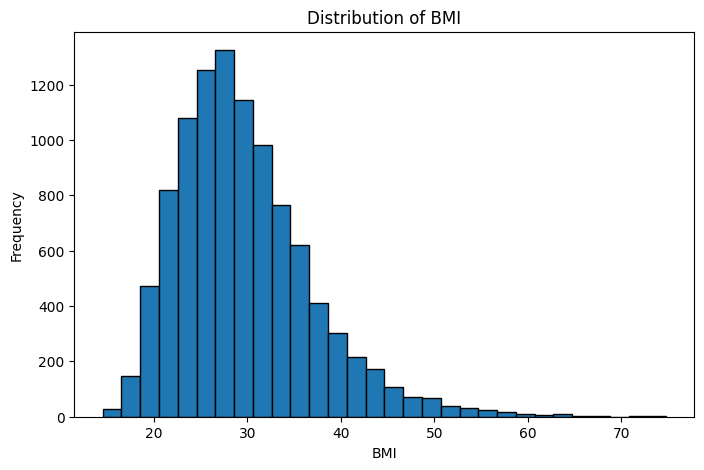

In [ ]:
# This is the histogram to see the distribution of BM
plt.figure(figsize=(8, 5))
plt.hist(df["bmi"], bins=30, edgecolor="black")
plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

<Figure size 800x500 with 0 Axes>

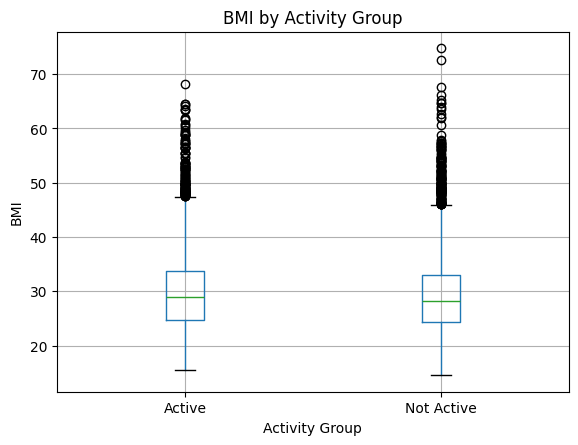

In [ ]:
# Create a boxplot to compare BMI across activity groups
plt.figure(figsize=(8, 5))
df.boxplot(column="bmi", by="activity_group")
plt.title("BMI by Activity Group")
plt.suptitle("")  # This part removes automatic extra title
plt.xlabel("Activity Group")
plt.ylabel("BMI")
plt.show()

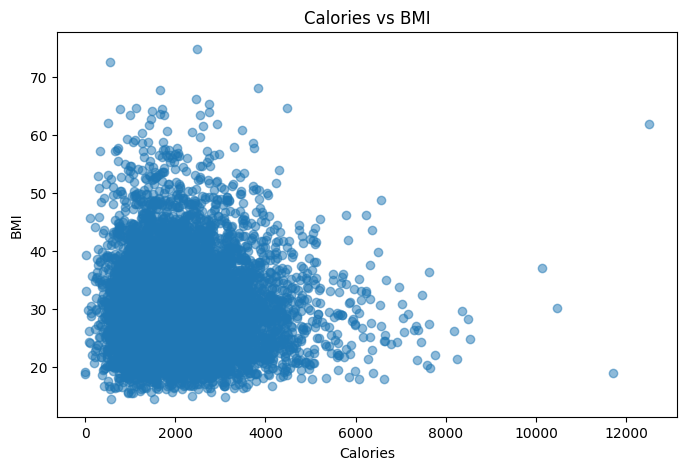

In [ ]:

# I decided to create a scatterplot to examine the relationship between calorie intake and BMI
plt.figure(figsize=(8, 5))
plt.scatter(df["calories"], df["bmi"], alpha=0.5)
plt.title("Calories vs BMI")
plt.xlabel("Calories")
plt.ylabel("BMI")
plt.show()

In [ ]:

# This will calculate correlations among numeric variables as it helps identify simple linear relationships
corr_matrix = df[["age", "bmi", "calories", "protein", "carbs", "fat"]].corr()

print("This is the correlation matrix:")
print(corr_matrix)

This is the correlation matrix:
               age       bmi  calories   protein     carbs       fat
age       1.000000  0.045935 -0.147540 -0.126879 -0.129244 -0.107487
bmi       0.045935  1.000000  0.000336 -0.009200 -0.024085  0.042927
calories -0.147540  0.000336  1.000000  0.774313  0.872007  0.884319
protein  -0.126879 -0.009200  0.774313  1.000000  0.539695  0.709667
carbs    -0.129244 -0.024085  0.872007  0.539695  1.000000  0.633686
fat      -0.107487  0.042927  0.884319  0.709667  0.633686  1.000000


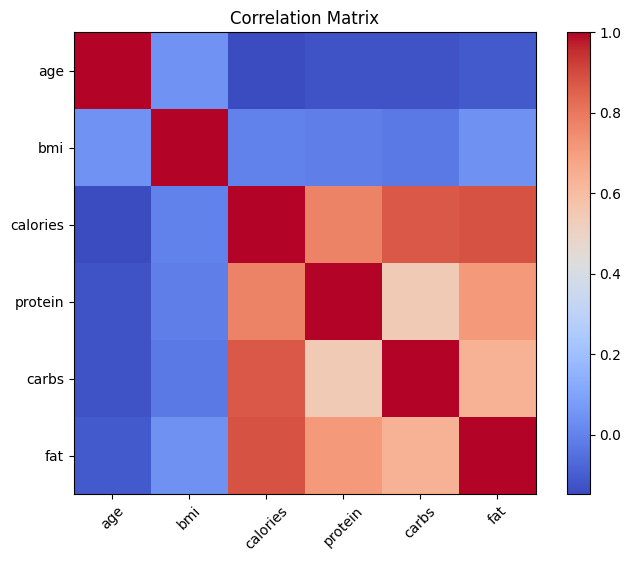

In [ ]:
# This was a suggestion from ChatGPT to use a colored matrix
plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, cmap="coolwarm", interpolation="none")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
from scipy.stats import ttest_ind

# I split the BMI into two groups based on the activity level
active_bmi = df[df["activity_group"] == "Active"]["bmi"]
not_active_bmi = df[df["activity_group"] == "Not Active"]["bmi"]

# This prints the sample sizes and group means that helps us understand the groups before testing
print("Active group size:", len(active_bmi))
print("Not Active group size:", len(not_active_bmi))

print("\nMean BMI (Active):", active_bmi.mean())
print("Mean BMI (Not Active):", not_active_bmi.mean())

# I began doing independent samples t-test.
# equal_var=False uses Welch's t-test, which is recommended to be a safer option
# when group variances may not be equal
t_stat, p_value = ttest_ind(active_bmi, not_active_bmi, equal_var=False)

# Print the test results
print("\nT-test results:")
print("T-statistic:", t_stat)
print("P-value:", p_value)

Active group size: 4607
Not Active group size: 5519

Mean BMI (Active): 29.939830692424568
Mean BMI (Not Active): 29.34665700308027

T-test results:
T-statistic: 4.102133353427426
P-value: 4.127000212838253e-05


In [ ]:
# This is the interpretation the p-value using a 0.05 significance level
alpha = 0.05

if p_value < alpha:
    print("\nConclusion: There is a statistically significant difference in BMI between the two activity groups.")
else:
    print("\nConclusion: There is no statistical significant difference in BMI between the two activity groups.")

NameError: name 'p_value' is not defined

In [ ]:

# Show standard deviations for both groups. This will give a description of the spread of BMI in each group
print("\nStandard deviation of BMI (Active):", active_bmi.std())
print("Standard deviation of BMI (Not Active):", not_active_bmi.std())


Standard deviation of BMI (Active): 7.329919252927522
Standard deviation of BMI (Not Active): 7.143951631380865


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# This is a copy of the cleaned dataset for modelling

model_df = df.copy()

# Defining predictor variables and target variable
X = model_df[[
    "age",
    "calories",
    "protein",
    "carbs",
    "fat",
    "activity_group",
    "gender"
]]

y = model_df["bmi"]

# This is the distribution:
# Split the data into 60% train, 20% validation, 20% test
# First: 60% train and 40% temporary
# Second: split temporary equally into validation and test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

# This will Print shapes to confirm the split
print("Training set size:", X_train.shape)
print("Validation set size:", X_val.shape)
print("Test set size:", X_test.shape)

# Separate numeric and categorical columns
numeric_features = ["age", "calories", "protein", "carbs", "fat"]
categorical_features = ["activity_group", "gender"]

# Preprocessing the numeric and categorical variables:
# - scale numeric variables
# - one-hot encode categorical variables
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features)
    ]
)

# Now I will build two models:
# 1. Linear Regression
# 2. Ridge Regression with a chosen alpha value
# This lets us compare a simple baseline with a regularized model
linear_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

# This will fit both models on the training set
linear_pipeline.fit(X_train, y_train)
ridge_pipeline.fit(X_train, y_train)

# Then I make predictions on the validation set
y_val_pred_linear = linear_pipeline.predict(X_val)
y_val_pred_ridge = ridge_pipeline.predict(X_val)

# This is the calculation for validation metrics based on the significance level
val_rmse_linear = mean_squared_error(y_val, y_val_pred_linear) ** 0.5
val_mae_linear = mean_absolute_error(y_val, y_val_pred_linear)

val_rmse_ridge = mean_squared_error(y_val, y_val_pred_ridge) ** 0.5
val_mae_ridge = mean_absolute_error(y_val, y_val_pred_ridge)

print("\nValidation results:")
print("Linear Regression RMSE:", val_rmse_linear)
print("Linear Regression MAE:", val_mae_linear)
print("Ridge Regression RMSE:", val_rmse_ridge)
print("Ridge Regression MAE:", val_mae_ridge)

# I am choosing the better model based on validation RMSE. This was another suggestion by ChatGPT
if val_rmse_linear <= val_rmse_ridge:
    final_model = linear_pipeline
    final_model_name = "Linear Regression"
else:
    final_model = ridge_pipeline
    final_model_name = "Ridge Regression"

print("\nSelected final model:", final_model_name)

y_test_pred = final_model.predict(X_test)

test_rmse = mean_squared_error(y_test, y_test_pred) ** 0.5
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("\nTest set results:")
print("Final Model:", final_model_name)
print("Test RMSE:", test_rmse)
print("Test MAE:", test_mae)
print("Test R-squared:", test_r2)

Training set size: (6075, 7)
Validation set size: (2025, 7)
Test set size: (2026, 7)

Validation results:
Linear Regression RMSE: 7.154021848941188
Linear Regression MAE: 5.4900978780711265
Ridge Regression RMSE: 7.154028599336086
Ridge Regression MAE: 5.49010425361477

Selected final model: Linear Regression

Test set results:
Final Model: Linear Regression
Test RMSE: 7.171675737218665
Test MAE: 5.485108308657418
Test R-squared: 0.02101345510668029


In [ ]:

# Extract feature names after preprocessing
feature_names = (
    numeric_features +
    list(final_model.named_steps["preprocessor"]
         .named_transformers_["cat"]
         .get_feature_names_out(categorical_features))
)

# Extract coefficients from the final model
coefficients = final_model.named_steps["model"].coef_

coef_df = pd.DataFrame({
    "Variable": feature_names,
    "Coefficient": coefficients
}).sort_values(by="Coefficient", key=abs, ascending=False)

print("\nModel coefficients:")
print(coef_df)

print("\nIntercept:", final_model.named_steps["model"].intercept_)


Model coefficients:
                    Variable  Coefficient
6                gender_Male    -1.282764
5  activity_group_Not Active    -0.932281
4                        fat     0.925332
0                        age     0.416114
1                   calories    -0.338190
3                      carbs    -0.179951
2                    protein    -0.146676

Intercept: 30.813578455201878


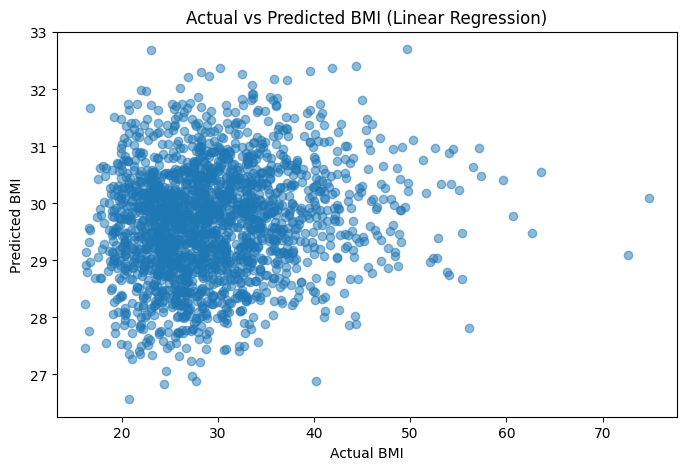

In [ ]:
import matplotlib.pyplot as plt

# This will make a scatterplot to plot actual BMI values against predicted BMI values for confirmation
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.title(f"Actual vs Predicted BMI ({final_model_name})")
plt.xlabel("Actual BMI")
plt.ylabel("Predicted BMI")
plt.show()

In [ ]:

# Save the cleaned dataset to a CSV file for the PowerBI
df.to_csv("Cleaned nhanes data.csv", index=False)

In [ ]:

# Save the regression coefficients to a CSV file
coef_df.to_csv("Regression Coefficients.csv", index=False)